# Lab 3 – Time Series Analysis (Annual Data)
### Thailand: GDP and Fossil Fuel Energy Consumption

Patthiya Pechmee

UNI: pp2951

## 1. Collect some time-ordered data (X and Y)

For this lab, I use annual World Bank data for Thailand.  
- **X (independent variable):** GDP (current US dollars)  
- **Y (dependent variable):** Fossil fuel energy consumption (% of total energy use)  

The dataset spans multiple decades, providing time-ordered observations that allow me to examine how Thailand’s economic development relates to its reliance on fossil fuels.


In [ ]:
import pandas as pd

gdp = pd.read_csv('/content/drive/My Drive/API_NY.GDP.MKTP.CD_DS2_en_csv_v2_2463.csv', skiprows=4)
fossil = pd.read_csv('/content/drive/My Drive/API_EG.USE.COMM.FO.ZS_DS2_en_csv_v2_8577.csv', skiprows=4)

gdp_th = gdp[gdp['Country Name'] == 'Thailand']
fossil_th = fossil[fossil['Country Name'] == 'Thailand']

gdp_long = gdp_th.melt(id_vars=['Country Name','Country Code','Indicator Name','Indicator Code'],
                       var_name='year', value_name='gdp')

fossil_long = fossil_th.melt(id_vars=['Country Name','Country Code','Indicator Name','Indicator Code'],
                             var_name='year', value_name='fossil')

gdp_long = gdp_long[['year', 'gdp']]
fossil_long = fossil_long[['year', 'fossil']]

df = pd.merge(gdp_long, fossil_long, on='year')

df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna()
df = df[df['year'] >= 1960]
df = df.sort_values('year').reset_index(drop=True)

df.head()

,year,gdp,fossil
0,1990.0,8.534319e+10,63.159301
1,1991.0,9.823471e+10,64.554117
2,1992.0,1.114527e+11,66.306584
3,1993.0,1.288893e+11,71.162781
4,1994.0,1.466838e+11,74.571478


## 2. Graph the relationship between X and Y

To begin, I examine the relationship between GDP (X) and fossil fuel use (Y) using two visualizations.

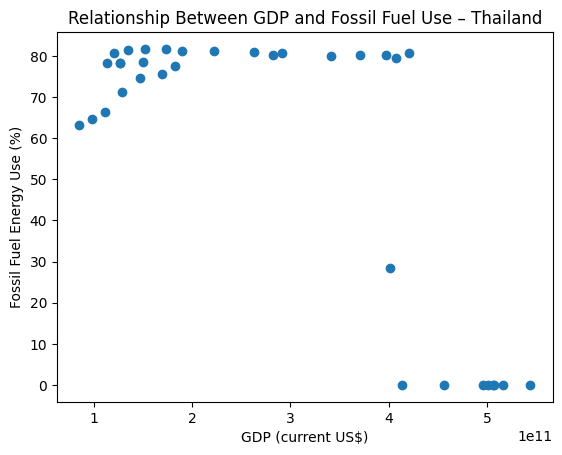

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['gdp'], df['fossil'])
plt.xlabel('GDP (current US$)')
plt.ylabel('Fossil Fuel Energy Use (%)')
plt.title('Relationship Between GDP and Fossil Fuel Use – Thailand')
plt.show()

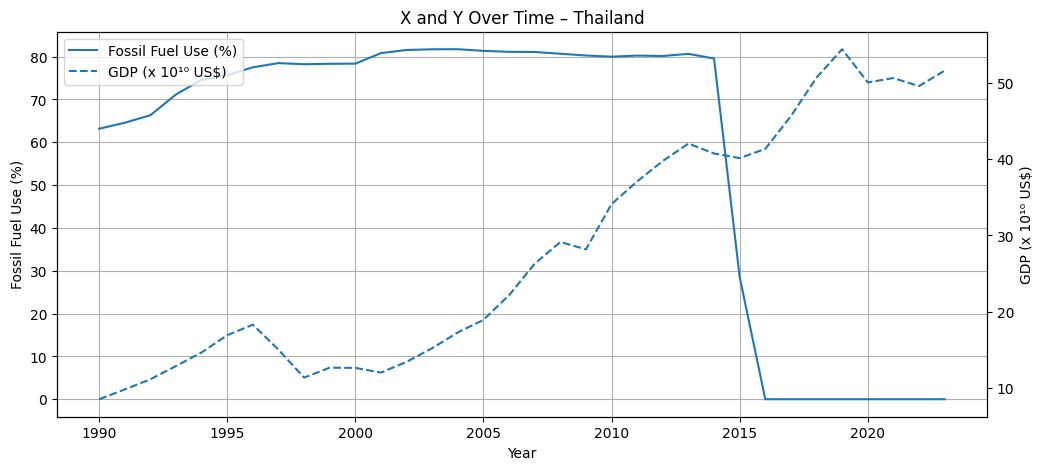

In [ ]:
plt.figure(figsize=(12, 5))
ax1 = plt.gca()

# Y
l1 = ax1.plot(df['year'], df['fossil'], label='Fossil Fuel Use (%)', linestyle='-')
ax1.set_ylabel('Fossil Fuel Use (%)')
ax1.set_xlabel('Year')

# X
ax2 = ax1.twinx()
gdp_scaled = df['gdp'] / 1e10
l2 = ax2.plot(df['year'], gdp_scaled, label='GDP (x 10¹⁰ US$)', linestyle='--')
ax2.set_ylabel('GDP (x 10¹⁰ US$)')

lines = l1 + l2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('X and Y Over Time – Thailand')
ax1.grid(True)
plt.show()


The scatterplot shows that the relationship between GDP and fossil fuel use is not linear. At lower GDP levels, fossil fuel use is high and stable, but at higher GDP levels, fossil fuel use drops sharply.

The time-series plot shows the same pattern over time: GDP rises steadily, while fossil fuel use stays high until around 2014, then declines to near zero. This suggests major changes in Thailand’s energy mix or policies in recent years.

Overall, the relationship between GDP and fossil fuel use appears complex and changes over time rather than moving together in a simple way.


## 3. Run an OLS model predicting Y as a function of X plus a time trend

In this section, I estimate an OLS regression model where fossil fuel energy use is the dependent variable and GDP is the main independent variable. I also include a time trend to account for overall changes over the years.

The model is:

\[
\text{Fossil}_t = \alpha + \beta_1 \text{GDP}_t + \beta_2 t + \varepsilon_t
\]

Below is the code used to estimate the OLS model.


In [ ]:
df['trend'] = range(1, len(df)+1)

ols1 = smf.ols('fossil ~ gdp + trend', data=df).fit()
print(ols1.summary())


                            OLS Regression Results                            
Dep. Variable:                 fossil   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.545
Method:                 Least Squares   F-statistic:                     20.80
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           1.87e-06
Time:                        23:00:14   Log-Likelihood:                -153.09
No. Observations:                  34   AIC:                             312.2
Df Residuals:                      31   BIC:                             316.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    103.9949      8.234     12.630      0.0

#### Interpretation of the OLS Model

The OLS model examines how GDP and a time trend are associated with Thailand’s fossil fuel energy use.

**GDP coefficient:** –2.168 × 10⁻¹⁰  
The GDP coefficient is negative and statistically significant (p = 0.016). This means that as GDP increases, fossil fuel energy use tends to decrease. For example, a $100 billion increase in GDP (1 × 10¹¹) is associated with about a **21.7 percentage-point drop** in fossil fuel dependence. This suggests that Thailand may have shifted toward cleaner or more diverse energy sources as the economy grew.

**Trend coefficient:** 0.8389  
The time trend is positive but not statistically significant (p = 0.528). After controlling for GDP, there is no strong long-term upward or downward trend in fossil fuel use.

**R-squared:** 0.573  
GDP and time explain about 57% of the variation in fossil fuel use, which indicates a reasonably good model fit for time-series data.

**Durbin–Watson:** 0.285  
This is far from 2, indicating **strong positive autocorrelation** in the residuals. This is expected in time-ordered data and motivates using first differencing in the next step.

I originally expected GDP to be positively related to fossil fuel use, assuming that economic growth would increase energ


## 4. First-Differenced OLS Model

In this section, I create first-differenced variables to remove trends and reduce autocorrelation in the time series. Differencing helps isolate **short-run changes** rather than long-run level relationships.

The differenced model is:

\[
\Delta \text{Fossil}_t = \gamma_0 + \gamma_1 \Delta \text{GDP}_t + \gamma_2 \Delta t + u_t
\]

Below is the code used to create the differenced data and run the OLS model.


In [ ]:
df['d_fossil'] = df['fossil'].diff()
df['d_gdp'] = df['gdp'].diff()
df['d_trend'] = df['trend'].diff()

df_diff = df.dropna().reset_index(drop=True)
df_diff.head()


,year,gdp,fossil,trend,d_fossil,d_gdp,d_trend
0,1991.0,9.823471e+10,64.554117,2,1.394816,1.289152e+10,1.0
1,1992.0,1.114527e+11,66.306584,3,1.752466,1.321803e+10,1.0
2,1993.0,1.288893e+11,71.162781,4,4.856197,1.743652e+10,1.0
3,1994.0,1.466838e+11,74.571478,5,3.408698,1.779452e+10,1.0
4,1995.0,1.692789e+11,75.659866,6,1.088388,2.259514e+10,1.0


In [ ]:
ols2 = smf.ols('d_fossil ~ d_gdp + d_trend', data=df_diff).fit()
print(ols2.summary())


                            OLS Regression Results                            
Dep. Variable:               d_fossil   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                    0.5230
Date:                Wed, 10 Dec 2025   Prob (F-statistic):              0.475
Time:                        23:04:33   Log-Likelihood:                -122.78
No. Observations:                  33   AIC:                             249.6
Df Residuals:                      31   BIC:                             252.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.3221      1.029     -1.284      0.2

#### Interpretation of the First-Differenced Model

The coefficient on ΔGDP is very small and not statistically significant. This means that year-to-year changes in GDP do not explain year-to-year changes in fossil fuel use. The differenced trend term is also not significant, which is expected because the trend does not vary much after differencing.

The R-squared of 0.017 shows that the model has almost no explanatory power in the short run. The Durbin–Watson statistic increases to 1.157, which indicates that differencing reduced autocorrelation compared to the levels model.

#### Comparison with the Original Model

Unlike the levels model, the differenced model does not show a significant effect of GDP, and the R-squared drops sharply. This suggests the strong relationship in the original model reflects long-term trends, not year-to-year fluctuations. Short-run GDP changes do not meaningfully predict short-run changes in fossil fuel use.

## 5. Graph the Relationship Between Change in X and Change in Y

The goal of this step is to examine whether short-run changes in GDP are linked to short-run changes in fossil fuel use. To do this, I plot ΔGDP against Δfossil fuel use and visually inspect whether changes in one variable tend to move together with the other.

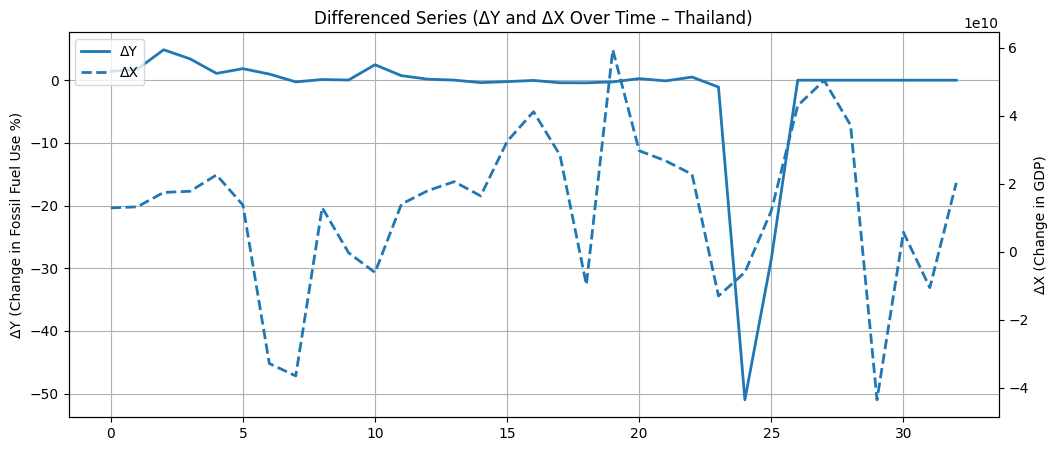

In [ ]:
# Plot differenced series (ΔY and ΔX)
plt.figure(figsize=(12, 5))
ax1 = plt.gca()

# ΔY
l1, = ax1.plot(df_diff.index, df_diff['d_fossil'], label='ΔY', linewidth=2)
ax1.set_ylabel("ΔY (Change in Fossil Fuel Use %)")

# Second axis for ΔX
ax2 = ax1.twinx()
l2, = ax2.plot(df_diff.index, df_diff['d_gdp'], label='ΔX', linestyle='--', linewidth=2)
ax2.set_ylabel("ΔX (Change in GDP)")

plt.title("Differenced Series (ΔY and ΔX Over Time – Thailand)")
ax1.grid(True)

# Combine legends from both axes
lines = [l1, l2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')

plt.show()


The plot below shows the differenced series for GDP (ΔX) and fossil fuel use (ΔY). ΔY is far more volatile than ΔX, with several sharp spikes and drops, while ΔX changes more gradually over time. There is no clear pattern where increases in ΔGDP align with increases in Δfossil fuel use.

This supports the differenced OLS results, which found no significant short-run relationship between GDP and fossil fuel use once long-term trends are removed.

###Conclusion

Overall, GDP does not appear to be a strong predictor of fossil fuel use for Thailand. The long-run model shows a weak but statistically significant relationship, while the short-run (differenced) model shows no meaningful association at all. The differenced plot also confirms that changes in GDP and changes in fossil fuel use do not move together.

This suggests that Thailand’s fossil fuel use is likely driven more by policy changes, energy transitions, or external shocks rather than by economic growth alone.